In [9]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("Coffee Shop Sales.csv")

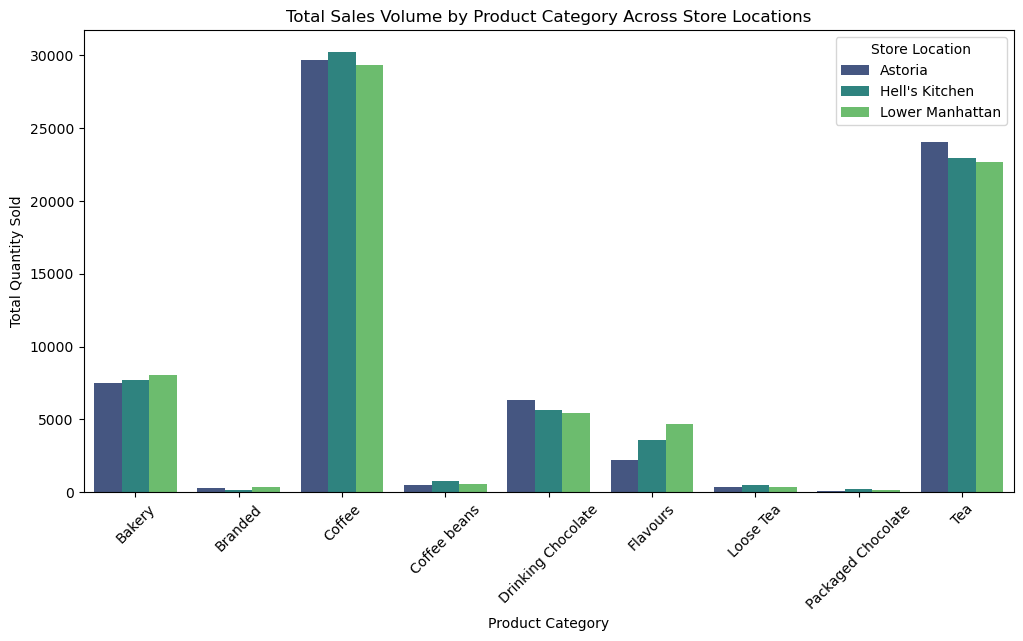

In [15]:
category_location_sales = df.groupby(['product_category', 'store_location'])['transaction_qty'].sum().reset_index()

# Plot with hue
plt.figure(figsize=(12, 6))
sns.barplot(x='product_category', y='transaction_qty', hue='store_location', data=category_location_sales, palette='viridis')
plt.title('Total Sales Volume by Product Category Across Store Locations')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.legend(title='Store Location')
plt.show()

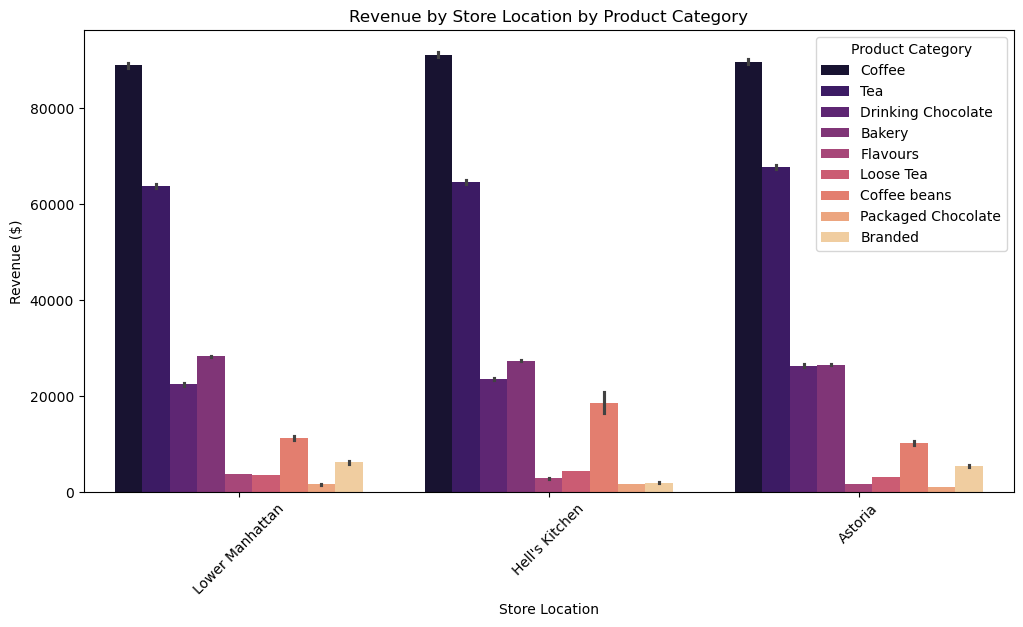

In [19]:
# Calculate revenue
df['revenue'] = df['transaction_qty'] * df['unit_price']
df.dropna(subset=['store_location', 'revenue', 'product_category'], inplace=True)

# Plot with hue
plt.figure(figsize=(12, 6))
sns.barplot(x='store_location', y='revenue', hue='product_category', data=df, palette='magma', estimator=sum)
plt.title('Revenue by Store Location by Product Category')
plt.xlabel('Store Location')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.legend(title='Product Category')
plt.show()

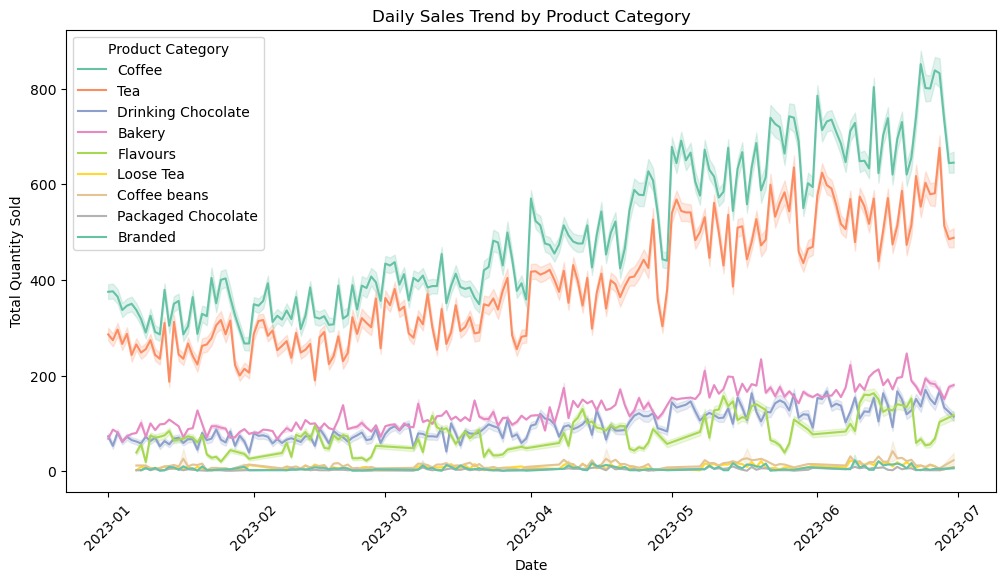

In [20]:
# Preprocess date
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df.dropna(subset=['transaction_date', 'transaction_qty', 'product_category'], inplace=True)

# Plot with hue
plt.figure(figsize=(12, 6))
sns.lineplot(x='transaction_date', y='transaction_qty', hue='product_category', data=df, estimator=sum, palette='Set2')
plt.title('Daily Sales Trend by Product Category')
plt.xlabel('Date')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.legend(title='Product Category')
plt.show()

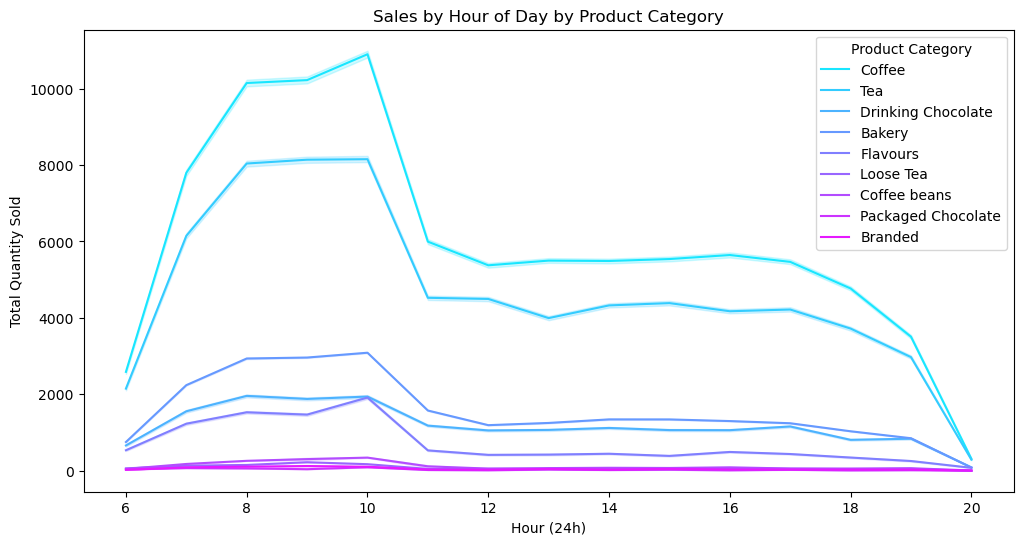

In [27]:
df['transaction_qty'] = pd.to_numeric(df['transaction_qty'], errors='coerce')
df.dropna(subset=['transaction_time', 'transaction_qty', 'product_category'], inplace=True)

# Parse transaction_time with AM/PM format and extract hour
df['hour'] = pd.to_datetime(df['transaction_time'], format='%I:%M:%S %p').dt.hour

# Plot with hue
plt.figure(figsize=(12, 6))
sns.lineplot(x='hour', y='transaction_qty', hue='product_category', data=df, estimator=sum, palette='cool')
plt.title('Sales by Hour of Day by Product Category')
plt.xlabel('Hour (24h)')
plt.ylabel('Total Quantity Sold')
plt.legend(title='Product Category')
plt.show()

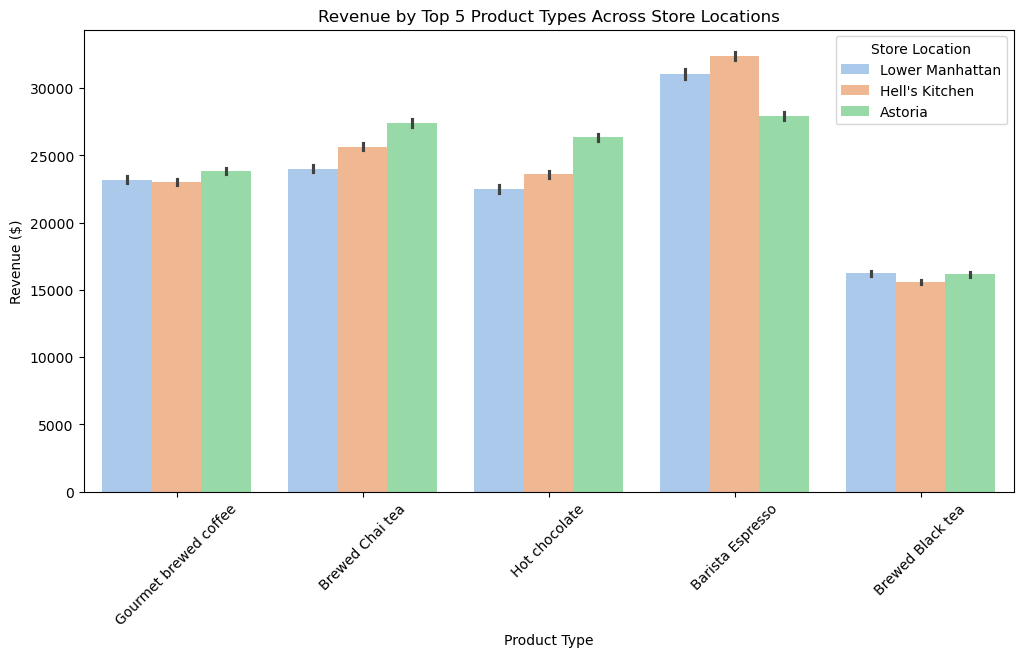

In [28]:
# Calculate revenue
df['revenue'] = df['transaction_qty'] * df['unit_price']
df.dropna(subset=['product_type', 'revenue', 'store_location'], inplace=True)

# Plot top 5 product types with hue
top_products = df.groupby('product_type')['revenue'].sum().nlargest(5).index
df_top = df[df['product_type'].isin(top_products)]

plt.figure(figsize=(12, 6))
sns.barplot(x='product_type', y='revenue', hue='store_location', data=df_top, palette='pastel', estimator=sum)
plt.title('Revenue by Top 5 Product Types Across Store Locations')
plt.xlabel('Product Type')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.legend(title='Store Location')
plt.show()